Using device: cuda
Downloaded 278,232 characters.
Raw cleaned text length: 227,509
First 500 characters:
eugene oneguine onegin  e-text prepared by stephen leary html file produced by david widger eugene onéguine onegin: a romance of russian life in verse by alexander pushkin translated from the russian by lieut.-col. henry spalding london: macmillan and co. 1881 preface eugene onéguine, the chief poetical work of russia’s greatest poet, having been translated into all the principal languages of europe except our own, i hope that this version may prove an acceptable contribution to literature. tast

Vocabulary size: 61
Sample characters:  !,-.0123456789:;?_abcdefghijklmnopqrstu

Encoded data shape: torch.Size([227509])
First 100 token IDs: [23, 39, 25, 23, 32, 23, 0, 33, 32, 23, 25, 39, 27, 32, 23, 0, 33, 32, 23, 25, 27, 32, 0, 0, 23, 3, 38, 23, 42, 38, 0, 34, 36, 23, 34, 19, 36, 23, 22, 0, 20, 43, 0, 37, 38, 23, 34, 26, 23, 32, 0, 30, 23, 19, 36, 43, 0, 26, 38, 31, 30, 0, 24, 27, 30, 

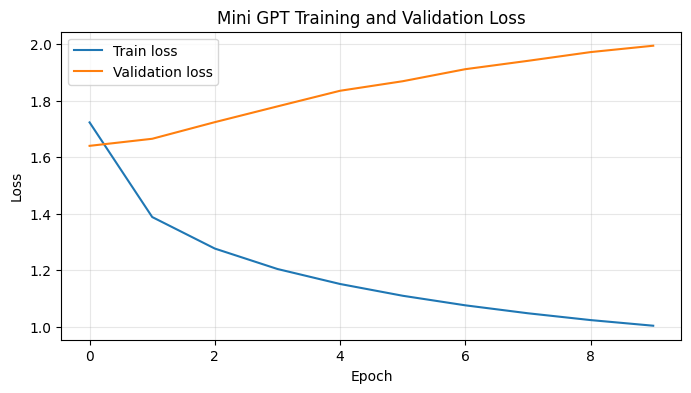


=== Generated Samples (Temperature=0.8, top-k=50) ===

1. Prompt: 'the moon rises over'
   Generated: the moon rises overcomed in bud with his line, the pale appeared to her the former of his period he
------------------------------------------------------------

2. Prompt: 'in the garden of'
   Generated: in the garden of his spirit sank “he decries of griboyédoff’s. practice estranged for sees, and 
------------------------------------------------------------

3. Prompt: 'love is like a'
   Generated: love is like a hardy passed him and had on all life and fetters to beguile provinally reply hi
------------------------------------------------------------

4. Prompt: 'the winter night'
   Generated: the winter night and without hopeless fools they remove on! the hour hath be! in soon saw, how t
------------------------------------------------------------

=== Greedy Sampling (Temperature=0.0) ===
Greedy: the moon rises overchance of russian poets have shone in the sneers of the real 

In [6]:
# =============================================================================
# Mini GPT: Decoder-only Transformer from Scratch
# Lecture Demo for Transformer-based Text Generation
# =============================================================================

"""
This notebook demonstrates a complete implementation of a GPT-style
decoder-only Transformer language model trained from scratch on
English translations of Alexander Pushkin's poetry.

Key components:
- Character-level tokenizer
- Causal language modeling objective (next-token prediction)
- Decoder-only Transformer (Multi-Head Self-Attention + FFN)
- Training loop with loss logging
- Text generation with greedy and stochastic sampling
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import re
from typing import Tuple, List, Optional

# Select device (GPU if available, otherwise CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# =============================================================================
# 1. DATASET: Pushkin Poems (English Translation)
# =============================================================================

import requests

# Project Gutenberg Eugene Onegin English translation (plain text, UTF-8)
# Main book page: https://www.gutenberg.org/ebooks/23997 [web:388]
TEXT_URL = "https://www.gutenberg.org/ebooks/23997.txt.utf-8"  # official plain text source [web:388]

def download_pushkin_text(url: str = TEXT_URL) -> str:
    """
    Download the full Eugene Onegin text from Project Gutenberg.

    This function fetches the plain text (UTF-8) version of the book and
    returns the raw string. In a production setting you might want to cache
    this to disk instead of downloading every time.
    """
    print(f"Downloading text from: {url}")
    resp = requests.get(url)
    resp.raise_for_status()
    raw = resp.text
    print(f"Downloaded {len(raw):,} characters.")
    return raw

def strip_gutenberg_header_footer(raw: str) -> str:
    """
    Strip the standard Project Gutenberg header and footer.

    Project Gutenberg texts usually contain license and metadata sections
    before and after the main content. We remove them using the standard
    '*** START/END OF THE PROJECT GUTENBERG EBOOK' markers when possible.
    """
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    if start_marker in raw and end_marker in raw:
        raw = raw.split(start_marker, 1)[-1]
        raw = raw.split(end_marker, 1)[0]
    else:
        # Fallback: if markers are missing (or different), we keep the whole text.
        print("Warning: Gutenberg start/end markers not found, using full text.")

    return raw

def clean_text(text: str) -> str:
    """
    Basic text cleaning for character-level language modeling.

    This function:
    - Lowercases the text.
    - Collapses multiple whitespace characters into a single space.
    - Keeps only word characters, whitespace, and a small set of punctuation.
    """
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\.\,\!\?\;\:\-\'\"“”‘’]", "", text)
    return text.strip()

# ---- Load and preprocess full book text ----
raw_text = download_pushkin_text(TEXT_URL)
raw_text = strip_gutenberg_header_footer(raw_text)
text = clean_text(raw_text)

print(f"Raw cleaned text length: {len(text):,}")
print("First 500 characters:")
print(text[:500])

# =============================================================================
# 1.1 Character-level Tokenizer
# =============================================================================

# Build character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_id = {ch: i for i, ch in enumerate(chars)}
id_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"\nVocabulary size: {vocab_size}")
print("Sample characters:", ''.join(chars[:40]))

def encode(text: str) -> torch.Tensor:
    """
    Encode a string into a tensor of token IDs (character-level).

    Args:
        text: Input string.

    Returns:
        1D tensor of dtype long containing token IDs.
    """
    return torch.tensor([char_to_id[c] for c in text], dtype=torch.long)

def decode(ids: torch.Tensor) -> str:
    """
    Decode a tensor of token IDs back into a string.

    Args:
        ids: 1D tensor of token IDs.

    Returns:
        Decoded string.
    """
    return ''.join(id_to_char[int(i)] for i in ids)

# Convert full text into a single long sequence of token IDs
data = encode(text)
print(f"\nEncoded data shape: {data.shape}")
print("First 100 token IDs:", data[:100].tolist())

# =============================================================================
# 1.2 Train / Validation Split and Dataset
# =============================================================================

# Split the long sequence into train and validation parts
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

# Context length (how many previous tokens the model can see)
block_size = 64
print(f"\nTrain size: {len(train_data):,}, Validation size: {len(val_data):,}")
print(f"Block size (context length): {block_size}")

class TextDataset(Dataset):
    """
    Character-level dataset for causal language modeling.

    For each index i, the dataset returns:
    - x: sequence of length block_size
    - y: same sequence shifted by one character to the right

    This corresponds to next-token prediction:
    p(x_{t+1} | x_{<=t})
    """

    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, idx: int):
        # We take a slice of length block_size + 1 and then split it into input and target
        chunk = self.data[idx : idx + self.block_size + 1]
        x = chunk[:-1]            # first block_size tokens
        y = chunk[1:]             # same sequence shifted by one
        return x, y

# Build DataLoaders
batch_size = 32
train_ds = TextDataset(train_data, block_size)
val_ds = TextDataset(val_data, block_size)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

# Inspect one batch
print("\nSample batch:")
x_sample, y_sample = next(iter(train_loader))
print(f"x_sample shape: {x_sample.shape}, y_sample shape: {y_sample.shape}")
print("Sample input (decoded):")
print(decode(x_sample[0]))
print("Sample target (decoded):")
print(decode(y_sample[0]))

# =============================================================================
# 2. MODEL: Mini GPT (Decoder-only Transformer)
# =============================================================================

class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention with causal masking.

    This module implements:
    - Linear projections for queries, keys and values.
    - Scaled dot-product attention across multiple heads.
    - Causal mask so that each position can only attend to current and past tokens.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Linear projections for Q, K, V and output
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for multi-head self-attention.

        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model).

        Returns:
            Output tensor of shape (batch_size, seq_len, d_model).
        """
        B, T, C = x.shape

        # Compute Q, K, V and split into heads
        q = self.w_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, n_heads, T, d_k)
        k = self.w_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, n_heads, T, d_k)
        v = self.w_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, n_heads, T, d_k)

        # Scaled dot-product attention scores: (B, n_heads, T, T)
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.d_k)

        # Build causal mask: positions cannot attend to future tokens
        # mask shape: (T, T), lower-triangular 1s
        mask = torch.tril(torch.ones(T, T, device=x.device))
        scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax over the last dimension (sequence dimension)
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to V
        attn_out = torch.matmul(attn_weights, v)  # (B, n_heads, T, d_k)

        # Concatenate heads back
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)  # (B, T, d_model)

        # Final linear projection
        out = self.w_o(attn_out)
        return out

class TransformerBlock(nn.Module):
    """
    Single decoder block of the Transformer.

    Structure:
    - LayerNorm + Multi-Head Self-Attention + residual connection
    - LayerNorm + Position-wise Feed-Forward Network + residual connection
    """

    def __init__(self, d_model: int, n_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for a single Transformer decoder block.

        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model).

        Returns:
            Output tensor of shape (batch_size, seq_len, d_model).
        """
        # Self-attention sub-layer with pre-norm and residual
        x_norm = self.norm1(x)
        attn_out = self.attn(x_norm)
        x = x + self.dropout(attn_out)

        # Feed-forward sub-layer with pre-norm and residual
        x_norm = self.norm2(x)
        ffn_out = self.ffn(x_norm)
        x = x + self.dropout(ffn_out)

        return x

class MiniGPT(nn.Module):
    """
    Decoder-only Transformer language model (GPT-style).

    Components:
    - Token embeddings
    - Positional embeddings
    - Stack of Transformer decoder blocks
    - Final LayerNorm and linear output head to logits over vocabulary
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 4,
        ff_dim: int = 512,
        block_size: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.block_size = block_size
        self.d_model = d_model

        # Token and positional embeddings
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)

        # Stack of decoder blocks
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)]
        )

        # Final normalization and output head
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(
        self,
        idx: torch.Tensor,
        targets: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Forward pass through the language model.

        Args:
            idx: Input token IDs, shape (batch_size, seq_len).
            targets: Target token IDs for next-token prediction,
                     same shape as idx, or None for inference.

        Returns:
            logits: Unnormalized scores over vocabulary, shape (B, T, vocab_size).
            loss: Cross-entropy loss (scalar) if targets is not None, else None.
        """
        B, T = idx.shape
        assert T <= self.block_size, "Sequence length exceeds block_size."

        # Embed tokens and positions
        tok_emb = self.token_emb(idx)  # (B, T, d_model)
        positions = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(positions)  # (T, d_model)
        x = tok_emb + pos_emb  # (B, T, d_model)

        # Pass through all Transformer blocks
        for block in self.blocks:
            x = block(x)

        # Final LayerNorm and output head
        x = self.ln_f(x)
        logits = self.head(x)  # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            # Flatten for cross-entropy
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
    ) -> torch.Tensor:
        """
        Generate new tokens autoregressively from a given prompt.

        Args:
            idx: Initial token IDs, shape (batch_size, seq_len).
            max_new_tokens: Number of tokens to generate.
            temperature: Sampling temperature. If 0.0 → greedy argmax.
            top_k: If not None, perform top-k sampling for stochastic decoding.

        Returns:
            Tensor of shape (batch_size, seq_len + max_new_tokens) 
            containing the full generated sequence (prompt + continuation).
        """
        for _ in range(max_new_tokens):
            # Ensure we do not exceed the context window
            idx_cond = idx[:, -self.block_size :]

            # Forward pass to get logits for current context
            logits, _ = self(idx_cond)

            # Focus on the logits for the last time step
            logits = logits[:, -1, :]  # (B, vocab_size)

            # Greedy decoding (no sampling) if temperature == 0
            if temperature == 0.0 or temperature is None:
                idx_next = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                # Apply temperature scaling
                logits = logits / temperature

                # Optional top-k filtering
                if top_k is not None:
                    k = min(top_k, logits.size(-1))
                    v, _ = torch.topk(logits, k)
                    # Everything below the kth largest logit is set to -inf
                    logits[logits < v[:, [-1]]] = float("-inf")

                # Convert to probabilities
                probs = F.softmax(logits, dim=-1)

                # Sample from the distribution
                idx_next = torch.multinomial(probs, num_samples=1)

            # Append the sampled token to the sequence
            idx = torch.cat([idx, idx_next], dim=1)

        return idx

# =============================================================================
# 3. TRAINING
# =============================================================================

# Instantiate the model
model = MiniGPT(
    vocab_size=vocab_size,
    d_model=128,
    n_heads=4,
    n_layers=4,
    ff_dim=512,
    block_size=block_size,
    dropout=0.1,
).to(DEVICE)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(
    f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

# Optimizer (AdamW is standard for Transformer-style models)
optimizer = optim.AdamW(model.parameters(), lr=6e-4, weight_decay=0.01)

def evaluate_loss(model: nn.Module, loader: DataLoader) -> float:
    """
    Evaluate average loss over a given DataLoader without gradient updates.

    Args:
        model: Language model to evaluate.
        loader: DataLoader providing (x, y) batches.

    Returns:
        Average loss over all batches.
    """
    model.eval()
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            _, loss = model(x, y)
            total_loss += loss.item()
            count += 1

    return total_loss / max(1, count)

def train_epoch(model: nn.Module, loader: DataLoader, optimizer: optim.Optimizer) -> float:
    """
    Single training epoch over the training DataLoader.

    Args:
        model: Language model to train.
        loader: Training DataLoader.
        optimizer: Optimizer.

    Returns:
        Average training loss over the epoch.
    """
    model.train()
    total_loss = 0.0

    for batch_idx, (x, y) in enumerate(loader):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        # Forward pass
        logits, loss = model(x, y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Optional gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx:4d}/{len(loader):4d} | loss = {loss.item():.4f}")

    avg_loss = total_loss / max(1, len(loader))
    return avg_loss

# Training configuration
num_epochs = 5
train_losses = []
val_losses = []

print("\n=== Training Mini GPT ===")
for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d} | train_loss = {train_loss:.4f} | val_loss = {val_loss:.4f}")

# Plot training and validation loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Mini GPT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =============================================================================
# 4. TEXT GENERATION
# =============================================================================

model.eval()

def generate_sample(
    prompt: str,
    max_tokens: int = 100,
    temperature: float = 0.8,
    top_k: Optional[int] = 50,
) -> str:
    """
    Generate a text continuation given a text prompt.

    Args:
        prompt: Initial text prompt in string form.
        max_tokens: Number of tokens to generate.
        temperature: Sampling temperature (0.0 for greedy).
        top_k: Top-k cutoff for stochastic sampling; None disables top-k.

    Returns:
        Generated text as a string (prompt + continuation).
    """
    # Encode prompt and ensure it fits within block_size
    prompt_ids = encode(prompt)
    prompt_ids = prompt_ids[-block_size:]
    context = prompt_ids.unsqueeze(0).to(DEVICE)  # (1, T)

    # Use model's generate method
    generated_ids = model.generate(
        context,
        max_new_tokens=max_tokens,
        temperature=temperature,
        top_k=top_k,
    )

    # Decode only the new part or entire sequence; here we decode everything
    return decode(generated_ids[0].cpu())

# Example prompts
prompts = [
    "the moon rises over",
    "in the garden of",
    "love is like a",
    "the winter night",
]

print("\n=== Generated Samples (Temperature=0.8, top-k=50) ===")
for i, prompt in enumerate(prompts, 1):
    print(f"\n{i}. Prompt: '{prompt}'")
    gen = generate_sample(prompt, max_tokens=80, temperature=0.8, top_k=50)
    print("   Generated:", gen)
    print("-" * 60)

print("\n=== Greedy Sampling (Temperature=0.0) ===")
greedy_text = generate_sample(
    "the moon rises over", temperature=0.0, max_tokens=100, top_k=None
)
print("Greedy:", greedy_text)